In [3]:
# Descargar el repositorio completo desde GitHub
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    # Código para Colab
    !rm -rf proyecto
    !git clone https://github.com/RosiMoreno/Geothermometers.git proyecto
    import os
    os.chdir("proyecto")
    print("Directorio actual:", os.getcwd())
else:
    print("Estás en Jupyter local: se usa el directorio actual.")

Estás en Jupyter local: se usa el directorio actual.


# GEOTÉRMOMETROS ACUOSOS

### **1. Geotermómetro de Na/K/Mg**
Cálculos siguiento 
Ver fuentes en la libreta del oneNote, también enlaces al código de cálculo de esta geotérmometro y figura. 

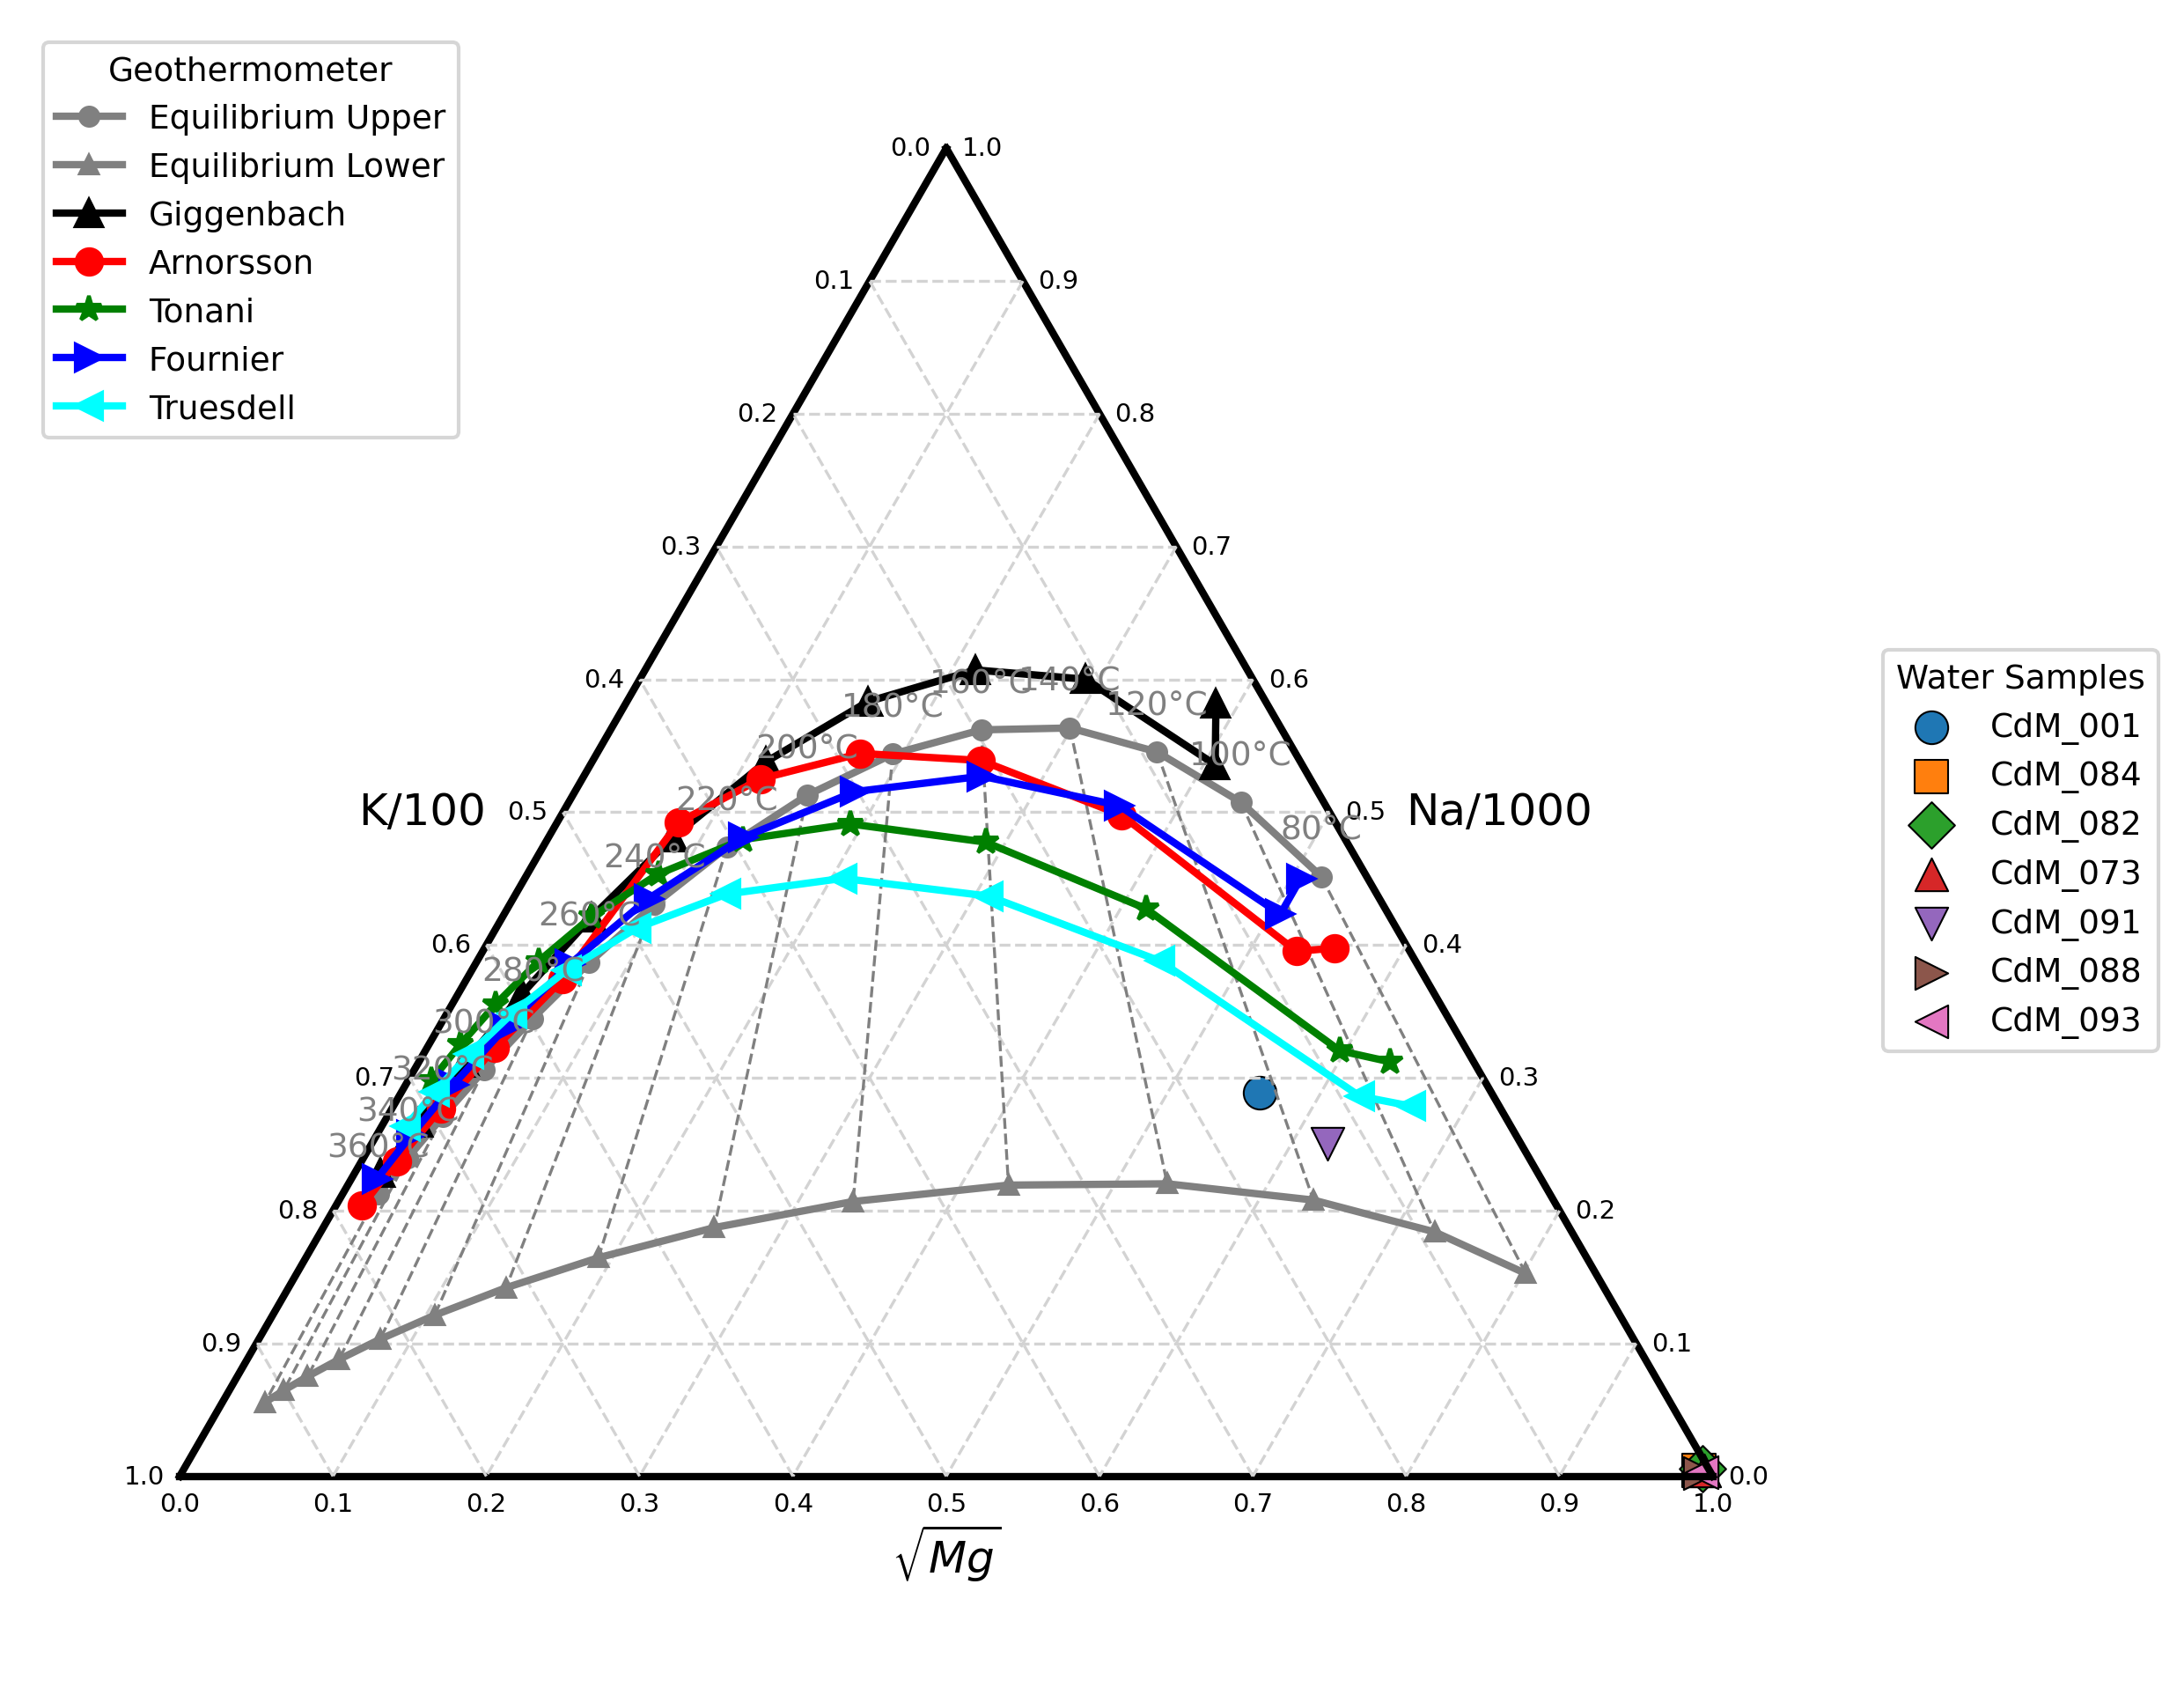

In [1]:
from IPython.display import Image
Image(r"Figures/Diagrama_Na_K_Mg_dic2026.png")

### **2. Geotermómetro de Na/K**
Cálculos siguiento 
[Carpio,2016](\References\Carpio-Interpretacion_hidroquimica_rio_Tambo.pdf)\
Tendencia a estimar temperaturas mayores que los geotérmometros de sílice.\
Se utilizan para aguas que hayan alcanzado el equilibrio \
Según [Informe,2016](\References\2015_Metodologia_geoquimica_aplicada_a_fluidos_geotermales.pdf) para Tª >250ºC

In [14]:
import math

# Concentraciones en mg/L
Na = 345
K = 18.1
Ca = 26.4

# Geotermómetros Na/K

def T_fournier(Na, K):
    log_NaK = math.log10(Na / K)
    return 1217 / (1.483 + log_NaK) - 273.15

def T_truesdell(Na, K):
    log_NaK = math.log10(Na / K)
    return 855.6 / (0.8573 + log_NaK) - 273.15

def T_giggenbach(Na, K):
    log_NaK = math.log10(Na / K)
    return 1390 / (1.75 + log_NaK) - 273.15

def T_arnorsson(Na, K):
    log_NaK = math.log10(Na / K)
    return 933 / (0.993 + log_NaK) - 273.15

def T_diaz(Na, K):
    log_NaK = math.log10(Na / K)
    return 833 / (0.908 + log_NaK) - 273.15


# Ejecución de cálculos

T_four = T_fournier(Na,K)
T_trues = T_truesdell(Na,K)
T_giggen = T_giggenbach(Na,K)
T_arnor = T_arnorsson(Na,K)
T_diaz2 = T_diaz(Na,K)
print("RESULTADOS")

print("Geotermómetro Na/K (°C):")
print(f"Fournier (1977):          {T_four:.2f} °C")
print(f"Truesdell (1976):         {T_trues:.2f} °C")
print(f"Giggenbach (1988):        {T_giggen:.2f} °C")
print(f"Arnórsson (1983):         {T_arnor:.2f} °C")
print(f"Díaz-González (2008):     {T_diaz2:.2f} °C")


RESULTADOS
Geotermómetro Na/K (°C):
Fournier (1977):          167.29 °C
Truesdell (1976):         127.14 °C
Giggenbach (1988):        185.57 °C
Arnórsson (1983):         137.30 °C
Díaz-González (2008):     107.54 °C


### **3. Geotermómetro de Na-K-Ca**
Cálculos siguiento 
[Carpio,2016](\References\Carpio-Interpretacion_hidroquimica_rio_Tambo.pdf)\
Según [Informe,2016](\References\2015_Metodologia_geoquimica_aplicada_a_fluidos_geotermales.pdf) para Tª >250ºC

In [15]:
# Pesos moleculares (g/mol)
MW_Na = 22.989
MW_K = 39.098
MW_Ca = 40.078

def mgL_to_molL(mgL, MW):
    return mgL / (1000 * MW)

Na_mol = mgL_to_molL(Na, MW_Na)
K_mol = mgL_to_molL(K, MW_K)
Ca_mol = mgL_to_molL(Ca, MW_Ca)

print(f"Na: {Na_mol:.6f} mol/L")
print(f"K:  {K_mol:.6f} mol/L")
print(f"Ca: {Ca_mol:.6f} mol/L")

# Función para calcular beta según la imagen
def calcular_beta(Ca, Na):
    log_sqrt_CaNa = math.log10(math.sqrt(Ca / Na))

    if log_sqrt_CaNa < 0:
        beta = 1/3
    else:
        beta = 4/3

    return beta, log_sqrt_CaNa
# Geotermómetro Na-K-Ca (Fournier & Truesdell 1974)
def T_extendido(Na_mol, K_mol, Ca_mol):
    log_NaK = math.log10(Na_mol / K_mol)
    beta, log_sqrt_CaNa = calcular_beta(Ca_mol, Na_mol)

    T = 1647 / (2.24 + log_NaK + beta * log_sqrt_CaNa) - 273.15
    return T, beta, log_sqrt_CaNa

# Ejecución de cálculos
T_ext, beta, log_sqrt_CaNa = T_extendido(Na_mol, K_mol, Ca_mol)
print("RESULTADOS")
print("\nGeotermómetro Na-K-Ca ")
print(f"log(√(Ca/Na)) = {log_sqrt_CaNa:.4f}")
print(f"β seleccionado = {beta:.2f}")
print(f"Temperatura (Fournier & Truesdell 1974) = {T_ext:.2f} °C")

Na: 0.015007 mol/L
K:  0.000463 mol/L
Ca: 0.000659 mol/L
RESULTADOS

Geotermómetro Na-K-Ca 
log(√(Ca/Na)) = -0.6788
β seleccionado = 0.33
Temperatura (Fournier & Truesdell 1974) = 194.15 °C


### Other sources to calculate cations geothermometers

In [16]:
# Geotermómetro Na-K-Ca (según Zhen-Zhang, 2025)
import math
Na=345
K=18.1
Ca=26.4
Mg=0.448

# según Fournier & Truesdell, 1973
#Tº de equilibrio >100ºC --> beta=1/3, 
#Tº de equilibrio <100ºC --> beta=4/3, 

T_NaKCa = round(1647/(math.log10(Na/K) + 1/3*(math.log10(math.sqrt(Ca)/Na)+2.06) +2.47) -273,2)
T_KMg = round(4410/(14 - math.log10(math.sqrt(K)/Mg)) -273,2)

T_NaKCa, T_KMg
print("T_NaKCa:", T_NaKCa)
print("T_KMg:", T_KMg)

T_NaKCa: 157.27
T_KMg: 65.65


### **4. Cálculo de Geotermómetro de SiO2 en Cuarzo**
Basado en la información de este informe [Gulec](\References\Gulec_Aplication_Geothermometry.pdf)\
Geotermómetros de cuarzo funcionan mejor para **aguas con Tª subsuperficiales superiores a 150ºC**\
T_q_no: **Quartz - no steam loss**\
T_q_max: **Quartz - max steam loss (100ºC)**\
T_ch: **Chalcedony (Fournier 1977)**\
T_ch2: **Chalcedony (Arnórsson 1983)**\
T_ac:**Alpha‑cristobalite**\
T_oc:**Opal‑CT**\
T_as: **Amorphous silica**

In [17]:

import math
SiO2=90.9

T_q_no = round(1309/(5.19-math.log10(SiO2)) - 273.15, 2)
T_q_max =round(1522/(5.75-math.log10(SiO2)) - 273.15,2)
T_ch =round(1032/(4.69-math.log10(SiO2)) - 273.15,2)
T_ch2 =round(1112/(4.91-math.log10(SiO2)) - 273.15,2)
T_ac =round(1000/(4.78-math.log10(SiO2)) - 273.15,2)
T_oc =round(781/(4.51-math.log10(SiO2)) - 273.15,2)
T_as =round(731/(4.52-math.log10(SiO2)) - 273.15,2)

print("Quartz - no steam loss:", T_q_no)
print("Quartz - max steam loss (100ºC):", T_q_max)
print("Chalcedony (Fournier 1977):", T_ch)
print("Chalcedony (Arnórsson 1983):", T_ch2)
print("Alpha‑cristobalite:", T_ac)
print("Opal‑CT:", T_oc)
print("Amorphous silica:", T_as)

Quartz - no steam loss: 131.93
Quartz - max steam loss (100ºC): 128.28
Chalcedony (Fournier 1977): 104.67
Chalcedony (Arnórsson 1983): 103.62
Alpha‑cristobalite: 81.28
Opal‑CT: 32.95
Amorphous silica: 12.24


## **Temperatura media de Geotermómetros acuosos**


In [18]:
import pandas as pd
T=[T_four,T_trues,T_giggen,T_arnor,T_diaz2,T_NaKCa,T_KMg,T_q_no,T_q_max,T_ch,T_ch2,T_ac,T_oc,T_as]
GeoT = ["T_four","T_trues","T_giggen","T_arnor","T_diaz2","T_NaKCa","T_KMg","T_q_no","T_q_max","T_ch","T_ch2","T_ac","T_oc","T_as"]

tabla_T = pd.DataFrame({"Pou Termal":T}, index=[GeoT])
tabla_T.describe()

,Pou Termal
count,14.000000
mean,110.195086
std,49.179655
min,12.240000
25%,86.865000
50%,117.340186
75%,135.954027
max,185.574601


In [19]:
tabla_T

,Pou Termal
T_four,167.290865
T_trues,127.141841
T_giggen,185.574601
T_arnor,137.295369
T_diaz2,107.538531
T_NaKCa,157.270000
T_KMg,65.650000
T_q_no,131.930000
T_q_max,128.280000
T_ch,104.670000


In [20]:
tabla_T_all = pd.DataFrame([T], columns=GeoT, index=["CdM_001"])
tabla_T_all


,T_four,T_trues,T_giggen,T_arnor,T_diaz2,T_NaKCa,T_KMg,T_q_no,T_q_max,T_ch,T_ch2,T_ac,T_oc,T_as
CdM_001,167.290865,127.141841,185.574601,137.295369,107.538531,157.27,65.65,131.93,128.28,104.67,103.62,81.28,32.95,12.24


In [21]:
T_media = round((T_four+T_trues+T_giggen+T_arnor+T_diaz2+T_NaKCa+T_KMg+T_q_no+T_q_max+T_ch+T_ch2+T_ac+T_oc+T_as)/14,2)
print(f"Temperatura media de los Geotermómetros es: {T_media:.2f} ºC")

T_media_especifica= round((T_four+T_trues+T_giggen+T_arnor+T_diaz2+T_q_no+T_q_max)/8, 2)
print(f"Temperatura media de los Geotermómetros especificos para las condiciones de Caldes de Montbui: {T_media_especifica:.2f} ºC")
tabla_T_all["T_media"] = T_media
tabla_T_all["T_media_espec"] = T_media_especifica
tabla_T_all

Temperatura media de los Geotermómetros es: 110.20 ºC
Temperatura media de los Geotermómetros especificos para las condiciones de Caldes de Montbui: 123.13 ºC


,T_four,T_trues,T_giggen,T_arnor,T_diaz2,T_NaKCa,T_KMg,T_q_no,T_q_max,T_ch,T_ch2,T_ac,T_oc,T_as,T_media,T_media_espec
CdM_001,167.290865,127.141841,185.574601,137.295369,107.538531,157.27,65.65,131.93,128.28,104.67,103.62,81.28,32.95,12.24,110.2,123.13


# Cáculo de la Profundidad de Circulación
Según [Zhen_Zhang_2025](\References\2025_Zhen_Zhang_.pdf)

In [22]:
# Datos de entrada
T1 = T_media_especifica     # °C, temperatura del reservorio
T2 = 15.39      # °C, temperatura del nivel isotérmico
G  = 0.33   # °C/m, gradiente geotérmico convertido de °C/100m a °C/m
h  = 10        # m, profundidad del nivel isotérmico

# Cálculo de profundidad de circulación
H = round(((T1 - T2) / G + h),2)

print("Profundidad de circulación H =", H, "m")

Profundidad de circulación H = 336.48 m
